# Recommender Systems using the MovieLens Dataset

This notebook explores different recommendation techniques using the MovieLens dataset.  
The goal is to implement both content-based and collaborative filtering approaches and
evaluate their performance.

The dataset contains movie information and user ratings which can be used to understand
user preferences and recommend similar movies.

## Installing Libraries

In [1]:
!pip install "numpy<2"

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92

In [1]:
!pip install scikit-surprise


In [2]:
!pip install shap

In [4]:
!unzip ml-latest-small.zip

Archive:  ml-latest-small.zip
replace ml-latest-small/links.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: ml-latest-small/links.csv  
  inflating: ml-latest-small/tags.csv  
  inflating: ml-latest-small/ratings.csv  
  inflating: ml-latest-small/README.txt  
  inflating: ml-latest-small/movies.csv  


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import shap

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

In [6]:
movies = pd.read_csv("ml-latest-small/movies.csv")
ratings = pd.read_csv("ml-latest-small/ratings.csv")

print("Movies dataset shape:", movies.shape)
print("Ratings dataset shape:", ratings.shape)

Movies dataset shape: (9742, 3)
Ratings dataset shape: (100836, 4)


## Dataset Overview

The MovieLens dataset contains information about movies and user ratings.

- `movies.csv` contains movie titles and genres.
- `ratings.csv` contains ratings given by users.

First, we inspect the structure of the dataset.

In [7]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [8]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [9]:
print("Number of unique users:", ratings['userId'].nunique())
print("Number of unique movies rated:", ratings['movieId'].nunique())
print("Total ratings:", len(ratings))

Number of unique users: 610
Number of unique movies rated: 9724
Total ratings: 100836


### Distribution of Ratings

Before building recommendation models, it is useful to understand how ratings are distributed.

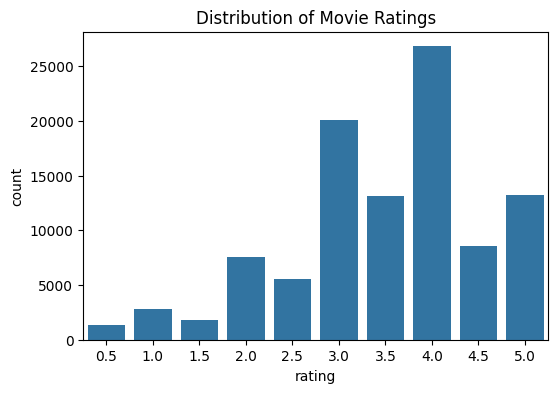

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=ratings)
plt.title("Distribution of Movie Ratings")
plt.show()

### Most Rated Movies

Some movies receive many ratings while others receive very few.  
The following code identifies the most frequently rated movies.

In [11]:
movie_ratings = ratings.groupby("movieId").size().sort_values(ascending=False)

movie_ratings.head()

,0
movieId,
356,329
318,317
296,307
593,279
2571,278


In [12]:
top_movies = movie_ratings.head(10).reset_index()
top_movies = top_movies.merge(movies, on="movieId")

top_movies[['title',0]]

,title,0
0,Forrest Gump (1994),329
1,"Shawshank Redemption, The (1994)",317
2,Pulp Fiction (1994),307
3,"Silence of the Lambs, The (1991)",279
4,"Matrix, The (1999)",278
5,Star Wars: Episode IV - A New Hope (1977),251
6,Jurassic Park (1993),238
7,Braveheart (1995),237
8,Terminator 2: Judgment Day (1991),224
9,Schindler's List (1993),220


## Preparing Movie Genre Features

Genres are stored as a list separated by `|`.  
For TF-IDF processing we convert them into space-separated text.

In [118]:
# Convert movie genres into text format for TF-IDF processing
movies['genres'] = movies['genres'].str.replace('|', ' ')

# Combine title and genre information into a single text field
movies['content'] = movies['title'] + " " + movies['genres']

movies.head()

,movieId,title,genres,content
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,Toy Story (1995) Adventure Animation Children ...
1,2,Jumanji (1995),Adventure Children Fantasy,Jumanji (1995) Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy Romance,Grumpier Old Men (1995) Comedy Romance
3,4,Waiting to Exhale (1995),Comedy Drama Romance,Waiting to Exhale (1995) Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy,Father of the Bride Part II (1995) Comedy


# Part 1: Content Based Filtering

Content-based filtering recommends movies based on the characteristics of the items.
In this implementation, we use textual information from movie titles and genres to
measure similarity between movies.

## Task 1: TF-IDF Based Movie Recommendation

In this task, we build a simple content-based recommender system using TF-IDF
(TF-IDF).

The movie title and genre information are combined to form a textual description
for each movie. These descriptions are then converted into TF-IDF feature vectors.

The overall steps are:

- Combine movie title and genre information to form text features.
- Convert the text into TF-IDF vectors using `TfidfVectorizer`.
- Compute cosine similarity between movie vectors.
- Given a movie title, return the top-N most similar movies.

### Creating TF-IDF Representation

Each movie genre description is converted into a TF-IDF vector which represents
the importance of each genre for that movie.

In [14]:
# Create TF-IDF vector representation of movie content
tfidf = TfidfVectorizer(stop_words='english')

# Transform movie descriptions into numerical feature vectors
tfidf_matrix = tfidf.fit_transform(movies['content'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (9742, 9060)


### Computing Movie Similarity

Cosine similarity is used to measure similarity between TF-IDF vectors.

In [15]:
# Compute cosine similarity between all movie vectors
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

cosine_sim.shape

(9742, 9742)

In [16]:
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

indices.head()

,0
title,
Toy Story (1995),0
Jumanji (1995),1
Grumpier Old Men (1995),2
Waiting to Exhale (1995),3
Father of the Bride Part II (1995),4


In [17]:
def recommend_movies(title, top_n=5):

    # find the index of the movie
    idx = indices[title]

    # similarity scores
    sim_scores = list(enumerate(cosine_sim[idx]))

    # sort movies based on similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # ignore the first one since it is the movie itself
    sim_scores = sim_scores[1:top_n+1]

    movie_indices = [i[0] for i in sim_scores]

    result = movies.iloc[movie_indices][['title']]

    result['similarity_score'] = [i[1] for i in sim_scores]

    return result

### Testing the Recommender

We test the recommender system using a few movie titles.

In [18]:
recommend_movies("Toy Story (1995)")

,title,similarity_score
2355,Toy Story 2 (1999),0.880446
7355,Toy Story 3 (2010),0.821047
3595,"Toy, The (1982)",0.538018
2539,We're Back! A Dinosaur's Story (1993),0.456423
26,Now and Then (1995),0.421651


In [19]:
recommend_movies("Batman (1989)")

,title,similarity_score
3390,K-9 (1989),0.634067
7731,Batman: Year One (2011),0.541105
5463,Batman (1966),0.537463
1060,Batman Returns (1992),0.535703
126,Batman Forever (1995),0.512891


## Task 2: User Profile Based Content Recommender

In this task, recommendations are personalized for each user based on their
past ratings. Instead of comparing movies directly with each other, we build
a user profile vector that represents the user's preferences.

The user profile is computed as a weighted combination of the TF-IDF vectors
of movies rated by the user. Movies rated higher contribute more to the user
profile than movies with lower ratings.

The profile vector is computed as:

Pu = (Σ (rating × movie_feature_vector)) / Σ ratings

Once the user profile is created, cosine similarity is used to find movies
that best match the user's preferences.

In [20]:
ratings_movies = ratings.merge(movies, on="movieId")

ratings_movies.head()

,userId,movieId,rating,timestamp,title,genres,content
0,1,1,4.0,964982703,Toy Story (1995),Adventure Animation Children Comedy Fantasy,Toy Story (1995) Adventure Animation Children ...
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy Romance,Grumpier Old Men (1995) Comedy Romance
2,1,6,4.0,964982224,Heat (1995),Action Crime Thriller,Heat (1995) Action Crime Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery Thriller,Seven (a.k.a. Se7en) (1995) Mystery Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime Mystery Thriller,"Usual Suspects, The (1995) Crime Mystery Thriller"


In [21]:
user_id = 1

user_data = ratings_movies[ratings_movies['userId'] == user_id]

user_data.head()

,userId,movieId,rating,timestamp,title,genres,content
0,1,1,4.0,964982703,Toy Story (1995),Adventure Animation Children Comedy Fantasy,Toy Story (1995) Adventure Animation Children ...
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy Romance,Grumpier Old Men (1995) Comedy Romance
2,1,6,4.0,964982224,Heat (1995),Action Crime Thriller,Heat (1995) Action Crime Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery Thriller,Seven (a.k.a. Se7en) (1995) Mystery Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime Mystery Thriller,"Usual Suspects, The (1995) Crime Mystery Thriller"


In [22]:
user_movies = user_data.merge(
    movies.reset_index(),
    on="movieId"
)

user_movies.head()

,userId,movieId,rating,timestamp,title_x,genres_x,content_x,index,title_y,genres_y,content_y
0,1,1,4.0,964982703,Toy Story (1995),Adventure Animation Children Comedy Fantasy,Toy Story (1995) Adventure Animation Children ...,0,Toy Story (1995),Adventure Animation Children Comedy Fantasy,Toy Story (1995) Adventure Animation Children ...
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy Romance,Grumpier Old Men (1995) Comedy Romance,2,Grumpier Old Men (1995),Comedy Romance,Grumpier Old Men (1995) Comedy Romance
2,1,6,4.0,964982224,Heat (1995),Action Crime Thriller,Heat (1995) Action Crime Thriller,5,Heat (1995),Action Crime Thriller,Heat (1995) Action Crime Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery Thriller,Seven (a.k.a. Se7en) (1995) Mystery Thriller,43,Seven (a.k.a. Se7en) (1995),Mystery Thriller,Seven (a.k.a. Se7en) (1995) Mystery Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime Mystery Thriller,"Usual Suspects, The (1995) Crime Mystery Thriller",46,"Usual Suspects, The (1995)",Crime Mystery Thriller,"Usual Suspects, The (1995) Crime Mystery Thriller"


In [23]:
rated_movie_indices = user_movies['index'].values

movie_vectors = tfidf_matrix[rated_movie_indices]

In [24]:
user_ratings = user_movies['rating'].values

In [25]:
user_profile = np.dot(user_ratings, movie_vectors.toarray())

user_profile = user_profile / user_ratings.sum()

user_profile.shape

(9060,)

In [26]:
user_similarity = cosine_similarity(
    user_profile.reshape(1,-1),
    tfidf_matrix
)

In [27]:
similar_scores = list(enumerate(user_similarity[0]))

similar_scores = sorted(similar_scores, key=lambda x: x[1], reverse=True)

top_movies = similar_scores[:10]

top_movies

[(6330, 0.5128640016225022),
 (5533, 0.4442450785334349),
 (8806, 0.44138287276442234),
 (5620, 0.43927173965644045),
 (422, 0.42616108420308113),
 (5396, 0.4213322331868811),
 (1972, 0.4200571593689588),
 (6140, 0.41830464279157553),
 (656, 0.4119683582355141),
 (2836, 0.41041885035696135)]

In [28]:
recommended_indices = [i[0] for i in top_movies]

recommended_movies = movies.iloc[recommended_indices][['title']]

recommended_movies['score'] = [i[1] for i in top_movies]

recommended_movies

,title,score
6330,Children of Men (2006),0.512864
5533,G.I. Joe: The Movie (1987),0.444245
8806,Home (2015),0.441383
5620,"Batman/Superman Movie, The (1998)",0.439272
422,Last Action Hero (1993),0.426161
5396,D.A.R.Y.L. (1985),0.421332
1972,"Mummy, The (1999)",0.420057
6140,Eight Below (2006),0.418305
656,Escape from L.A. (1996),0.411968
2836,X-Men (2000),0.410419


In [29]:
def recommend_for_user(user_id, top_n=10):

    user_data = ratings_movies[ratings_movies['userId'] == user_id]

    user_movies = user_data.merge(movies.reset_index(), on="movieId")

    rated_movie_indices = user_movies['index'].values

    movie_vectors = tfidf_matrix[rated_movie_indices]

    user_ratings = user_movies['rating'].values

    user_profile = np.dot(user_ratings, movie_vectors.toarray())
    user_profile = user_profile / user_ratings.sum()

    similarity = cosine_similarity(user_profile.reshape(1,-1), tfidf_matrix)

    scores = list(enumerate(similarity[0]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    # remove movies already rated by the user
    rated_movies = set(user_movies['index'])
    scores = [s for s in scores if s[0] not in rated_movies]

    top = scores[:top_n]

    indices = [i[0] for i in top]

    result = movies.iloc[indices][['title']]
    result['score'] = [i[1] for i in top]

    return result

In [30]:
def evaluate_user(user_id, k=10):

    user_data = ratings[ratings['userId'] == user_id]

    # relevant movies (rating >=4)
    relevant_movies = set(user_data[user_data['rating'] >= 4]['movieId'])

    recs = recommend_for_user(user_id, top_n=50)

    rec_movie_ids = set(
        movies[movies['title'].isin(recs['title'])]['movieId']
    )

    true_positive = len(relevant_movies & rec_movie_ids)

    precision = true_positive / 50
    recall = true_positive / len(relevant_movies)

    return precision, recall

In [31]:
recommend_for_user(2)

,title,score
7610,The Man from Nowhere (2010),0.441595
7343,Please Give (2010),0.408061
7419,I'm Still Here (2010),0.408061
7623,Everything Must Go (2010),0.408061
8057,Fire with Fire (2012),0.395436
7462,Somewhere (2010),0.387569
8767,I'm Here (2010),0.387569
7461,"Next Three Days, The (2010)",0.383914
7185,2012 (2009),0.376234
4940,Man on Fire (2004),0.363234


In [32]:
recommend_for_user(17)

,title,score
6330,Children of Men (2006),0.452655
2815,F/X (1986),0.417527
167,Strange Days (1995),0.406135
3569,"One, The (2001)",0.401550
7185,2012 (2009),0.396060
2248,RoboCop (1987),0.394644
4940,Man on Fire (2004),0.392795
454,RoboCop 3 (1993),0.389474
6140,Eight Below (2006),0.388157
400,"Getaway, The (1994)",0.385923


In [33]:
evaluate_user(3)

(0.02, 0.0625)

### Evaluation Result

The computed Precision and Recall values may be low or even zero for some
users. This occurs because the recommender system often suggests movies that
the user has not previously rated. Since the evaluation compares recommended
movies only with historical ratings, there may be little or no overlap.

In real-world recommender systems, evaluation is typically performed using a
proper train-test split or cross-validation where some ratings are hidden
during training and later used to verify recommendation accuracy.

### Observations

The recommendations generated using the user profile approach differ for each user,
since the profile vector is constructed from the movies they previously rated.

For example, User 1 and User 15 receive different recommendations because their
rating histories lead to different preference vectors. Movies recommended tend to
share similar genres with the movies that the user rated highly.

This shows that the user-profile based recommender is able to personalize
recommendations using historical user ratings.

# Part 2: Collaborative Filtering

Collaborative filtering recommends items based on the behavior of users rather
than item attributes. The basic assumption is that users who had similar tastes
in the past will likely prefer similar items in the future.

In this section we implement:

- User-based collaborative filtering
- Item-based collaborative filtering

## Task 3: User-Based Collaborative Filtering

User-based collaborative filtering finds users with similar rating patterns.
If two users rate many movies similarly, the system assumes their tastes are
similar and uses those users to generate recommendations.

In [34]:
# Create a user–movie rating matrix
user_movie_matrix = ratings.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

user_movie_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute similarity between users based on rating patterns
user_similarity = cosine_similarity(user_movie_matrix.fillna(0))

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)

user_similarity_df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.027283,0.059720,0.194395,0.129080,0.128152,0.158744,0.136968,0.064263,0.016875,...,0.080554,0.164455,0.221486,0.070669,0.153625,0.164191,0.269389,0.291097,0.093572,0.145321
2,0.027283,1.000000,0.000000,0.003726,0.016614,0.025333,0.027585,0.027257,0.000000,0.067445,...,0.202671,0.016866,0.011997,0.000000,0.000000,0.028429,0.012948,0.046211,0.027565,0.102427
3,0.059720,0.000000,1.000000,0.002251,0.005020,0.003936,0.000000,0.004941,0.000000,0.000000,...,0.005048,0.004892,0.024992,0.000000,0.010694,0.012993,0.019247,0.021128,0.000000,0.032119
4,0.194395,0.003726,0.002251,1.000000,0.128659,0.088491,0.115120,0.062969,0.011361,0.031163,...,0.085938,0.128273,0.307973,0.052985,0.084584,0.200395,0.131746,0.149858,0.032198,0.107683
5,0.129080,0.016614,0.005020,0.128659,1.000000,0.300349,0.108342,0.429075,0.000000,0.030611,...,0.068048,0.418747,0.110148,0.258773,0.148758,0.106435,0.152866,0.135535,0.261232,0.060792


In [36]:
def get_similar_users(user_id, n=5):

    similar_users = user_similarity_df[user_id].sort_values(ascending=False)

    similar_users = similar_users.drop(user_id)

    return similar_users.head(n)

In [37]:
get_similar_users(1)

,1
userId,
266,0.357408
313,0.351562
368,0.345127
57,0.345034
91,0.334727


In [38]:
def predict_rating(user_id, movie_id, n_neighbors=5):

    similar_users = get_similar_users(user_id, n_neighbors)

    ratings = user_movie_matrix[movie_id]

    weighted_ratings = 0
    similarity_sum = 0

    for other_user, similarity in similar_users.items():

        rating = ratings.get(other_user)

        if not np.isnan(rating):
            weighted_ratings += similarity * rating
            similarity_sum += similarity

    if similarity_sum == 0:
        return 0

    return weighted_ratings / similarity_sum

In [39]:
def recommend_cf(user_id, top_n=10):

    movies_not_rated = user_movie_matrix.loc[user_id]
    movies_not_rated = movies_not_rated[movies_not_rated.isna()].index

    predictions = []

    for movie_id in movies_not_rated:
        pred = predict_rating(user_id, movie_id)
        predictions.append((movie_id, pred))

    predictions = sorted(predictions, key=lambda x: x[1], reverse=True)

    top_movies = predictions[:top_n]

    movie_ids = [m[0] for m in top_movies]

    results = movies[movies['movieId'].isin(movie_ids)][['title']]

    results['predicted_rating'] = [m[1] for m in top_movies]

    return results

In [40]:
recommend_cf(5)

,title,predicted_rating
10,"American President, The (1995)",5.000000
13,Nixon (1995),5.000000
24,Leaving Las Vegas (1995),5.000000
202,French Kiss (1995),4.654903
253,Outbreak (1995),4.406271
314,Forrest Gump (1994),4.200561
334,Speed (1994),4.046790
505,Ghost (1990),4.003216
510,"Silence of the Lambs, The (1991)",4.000000
615,Independence Day (a.k.a. ID4) (1996),4.000000


In [41]:
recommend_cf(8)

,title,predicted_rating
0,Toy Story (1995),5.000000
124,Rob Roy (1995),5.000000
134,Crimson Tide (1995),4.507160
190,Clerks (1994),4.008151
191,Don Juan DeMarco (1995),4.000000
228,Like Water for Chocolate (Como agua para choco...,4.000000
412,In the Line of Fire (1993),4.000000
434,Much Ado About Nothing (1993),4.000000
443,Philadelphia (1993),4.000000
615,Independence Day (a.k.a. ID4) (1996),4.000000


### Observation

User-based collaborative filtering recommends movies by identifying users
with similar rating behavior. The predicted ratings are computed using a
weighted average of ratings from similar users. Movies with higher predicted
ratings are considered stronger recommendations for the target user.

## Task 4: Item-Based Collaborative Filtering

Item-based collaborative filtering recommends movies based on the
similarity between items rather than similarity between users.

The key idea is that if many users rate two movies similarly,
those movies are likely to be related. Therefore, if a user liked
a particular movie, the system can recommend other movies that
are similar to it.

In this implementation we compute similarity between movies
using cosine similarity on the user–movie rating matrix.

In [42]:
movie_user_matrix = user_movie_matrix.T

movie_user_matrix.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,NaN,NaN,4.0,NaN,4.5,NaN,NaN,NaN,...,4.0,NaN,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,NaN,NaN,NaN,NaN,NaN,4.0,NaN,4.0,NaN,NaN,...,NaN,4.0,NaN,5.0,3.5,NaN,NaN,2.0,NaN,NaN
3,4.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
movie_similarity = cosine_similarity(movie_user_matrix.fillna(0))

movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=movie_user_matrix.index,
    columns=movie_user_matrix.index
)

movie_similarity_df.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
movieId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.410562,0.296917,0.035573,0.308762,0.376316,0.277491,0.131629,0.232586,0.395573,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.410562,1.000000,0.282438,0.106415,0.287795,0.297009,0.228576,0.172498,0.044835,0.417693,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.296917,0.282438,1.000000,0.092406,0.417802,0.284257,0.402831,0.313434,0.304840,0.242954,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.035573,0.106415,0.092406,1.000000,0.188376,0.089685,0.275035,0.158022,0.000000,0.095598,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.308762,0.287795,0.417802,0.188376,1.000000,0.298969,0.474002,0.283523,0.335058,0.218061,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [44]:
def get_similar_movies(movie_id, n=5):

    similar = movie_similarity_df[movie_id].sort_values(ascending=False)

    similar = similar.drop(movie_id)

    return similar.head(n)

In [45]:
get_similar_movies(1)

,1
movieId,
3114,0.572601
480,0.565637
780,0.564262
260,0.557388
356,0.547096


In [46]:
def recommend_item_cf(user_id, top_n=10):

    user_ratings = user_movie_matrix.loc[user_id]

    rated_movies = user_ratings[user_ratings.notna()]

    scores = {}

    for movie_id, rating in rated_movies.items():

        similar_movies = movie_similarity_df[movie_id]

        for sim_movie, sim_score in similar_movies.items():

            if sim_movie not in rated_movies.index:

                if sim_movie not in scores:
                    scores[sim_movie] = 0

                scores[sim_movie] += sim_score * rating

    scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    top_movies = scores[:top_n]

    movie_ids = [m[0] for m in top_movies]

    results = movies[movies['movieId'].isin(movie_ids)][['title']]

    results['score'] = [m[1] for m in top_movies]

    return results

In [47]:
recommend_item_cf(4)

,title,score
705,Citizen Kane (1941),221.358226
828,Reservoir Dogs (1992),215.959838
836,E.T. the Extra-Terrestrial (1982),215.462621
909,Apocalypse Now (1979),213.922116
1005,When Harry Met Sally... (1989),213.424545
1074,Raising Arizona (1987),212.893446
2038,Ghostbusters (a.k.a. Ghost Busters) (1984),212.407170
2103,Big (1988),211.901697
2195,Ferris Bueller's Day Off (1986),211.383120
2250,Who Framed Roger Rabbit? (1988),210.382708


In [48]:
recommend_item_cf(15)

,title,score
1267,"Truman Show, The (1998)",180.687877
3614,Ocean's Eleven (2001),179.376609
3819,Spider-Man (2002),177.425453
3854,"Bourne Identity, The (2002)",174.569546
4351,"Matrix Reloaded, The (2003)",172.900184
4427,Pirates of the Caribbean: The Curse of the Bla...,172.356419
4800,"Lord of the Rings: The Return of the King, The...",171.336600
5850,Sin City (2005),170.124478
5917,Batman Begins (2005),169.407053
6151,V for Vendetta (2006),168.667929


### Observation

The scores produced by the item-based recommender represent
aggregated similarity contributions from multiple movies that
the user has rated. These scores are used only for ranking
movies, so larger values simply indicate stronger recommendation
strength rather than predicted rating values.

# Part 3: Matrix Factorization for Recommender Systems

Matrix factorization is a popular technique used in recommender systems
to discover hidden relationships between users and items. Instead of
directly comparing users or movies, matrix factorization learns latent
factors that represent underlying preferences.

In this section we implement recommendation using Singular Value
Decomposition (SVD).

## Task 5: Implementing SVD for Recommendations

Singular Value Decomposition (SVD) factorizes the user–movie rating
matrix into three matrices:

R ≈ U × Σ × Vᵀ

Where:
- U represents user latent features
- Σ represents singular values
- Vᵀ represents movie latent features

Using these matrices we can reconstruct the rating matrix and predict
missing ratings.

In [49]:
rating_matrix = user_movie_matrix.fillna(0)

rating_matrix.shape

(610, 9724)

In [50]:
from numpy.linalg import svd

# Perform Singular Value Decomposition for matrix factorization
U, sigma, Vt = svd(rating_matrix, full_matrices=False)

print(U.shape)
print(sigma.shape)
print(Vt.shape)

(610, 610)
(610,)
(610, 9724)


In [51]:
sigma_diag = np.diag(sigma)

In [52]:
k = 50

U_k = U[:, :k]
sigma_k = sigma_diag[:k, :k]
Vt_k = Vt[:k, :]

In [53]:
predicted_ratings = np.dot(np.dot(U_k, sigma_k), Vt_k)

predicted_ratings.shape

(610, 9724)

In [54]:
predicted_df = pd.DataFrame(
    predicted_ratings,
    index=rating_matrix.index,
    columns=rating_matrix.columns
)

predicted_df.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,2.181872,0.393674,0.838186,-0.082365,-0.546279,2.521662,-0.887231,-0.025221,0.196969,1.606758,...,-0.024984,-0.021415,-0.028553,-0.028553,-0.024984,-0.028553,-0.024984,-0.024984,-0.024984,-0.058988
2,0.209809,0.004821,0.030742,0.017252,0.183764,-0.060660,0.083306,0.023797,0.048100,-0.151968,...,0.018895,0.016196,0.021594,0.021594,0.018895,0.021594,0.018895,0.018895,0.018895,0.031966
3,0.013394,0.034726,0.050525,0.000200,-0.005577,0.114673,-0.007461,0.000738,0.004747,-0.061284,...,-0.001612,-0.001382,-0.001843,-0.001843,-0.001612,-0.001843,-0.001612,-0.001612,-0.001612,-0.000530
4,2.012072,-0.394882,-0.290386,0.093864,0.123312,0.259765,0.472667,0.035965,0.011293,-0.021983,...,0.001966,0.001685,0.002247,0.002247,0.001966,0.002247,0.001966,0.001966,0.001966,-0.021462
5,1.336714,0.772954,0.064577,0.113880,0.274994,0.584480,0.251048,0.131534,-0.086310,1.035361,...,-0.004407,-0.003778,-0.005037,-0.005037,-0.004407,-0.005037,-0.004407,-0.004407,-0.004407,-0.006099


In [55]:
def recommend_svd(user_id, top_n=10):

    user_predictions = predicted_df.loc[user_id]

    movies_already_rated = user_movie_matrix.loc[user_id].dropna().index

    recommendations = user_predictions.drop(movies_already_rated)

    recommendations = recommendations.sort_values(ascending=False)

    top_movies = recommendations.head(top_n)

    results = movies[movies['movieId'].isin(top_movies.index)][['title']]

    results['predicted_rating'] = top_movies.values

    return results

In [56]:
recommend_svd(1)

,title,predicted_rating
659,"Godfather, The (1972)",4.009045
793,Die Hard (1988),3.303897
922,"Godfather: Part II, The (1974)",3.303409
958,Stand by Me (1986),2.869847
1067,Jaws (1975),2.859630
1445,"Breakfast Club, The (1985)",2.785549
1544,Lady and the Tramp (1955),2.603560
1545,"Little Mermaid, The (1989)",2.455787
2110,"Christmas Story, A (1983)",2.403890
2996,Snatch (2000),2.372148


In [57]:
recommend_svd(10)

,title,predicted_rating
277,"Shawshank Redemption, The (1994)",1.902384
3568,"Monsters, Inc. (2001)",1.869723
3574,Harry Potter and the Sorcerer's Stone (a.k.a. ...,1.826364
3614,Ocean's Eleven (2001),1.819762
3622,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",1.805213
4076,Harry Potter and the Chamber of Secrets (2002),1.693067
4427,Pirates of the Caribbean: The Curse of the Bla...,1.656123
5166,Harry Potter and the Prisoner of Azkaban (2004),1.564796
7302,How to Train Your Dragon (2010),1.453806
7372,Inception (2010),1.451678


### Observation

Matrix factorization using SVD captures hidden relationships between
users and movies through latent factors. Instead of relying only on
direct similarity, the model learns underlying preference patterns,
which can lead to more accurate recommendations compared to basic
collaborative filtering methods.

## Task 6: Matrix Factorization using the Surprise Library

In this task we implement matrix factorization using the Surprise
library. Surprise provides built-in implementations of several
recommender algorithms including SVD, KNN and baseline methods.

Using Surprise simplifies the process of training and evaluating
recommendation models and allows us to compute evaluation metrics
such as RMSE.

In [62]:
!pip install "numpy<2"

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92

In [58]:
from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

In [59]:
reader = Reader(rating_scale=(0.5, 5))

data = Dataset.load_from_df(
    ratings[['userId','movieId','rating']],
    reader
)

In [60]:
trainset, testset = train_test_split(data, test_size=0.2)

In [61]:
svd_model = SVD()

svd_model.fit(trainset)

In [62]:
predictions = svd_model.test(testset)

In [63]:
accuracy.rmse(predictions)

RMSE: 0.8754


0.8753916676151451

In [64]:
def recommend_surprise(user_id, top_n=10):

    all_movies = ratings['movieId'].unique()
    rated_movies = ratings[ratings['userId']==user_id]['movieId'].values

    movies_to_predict = [m for m in all_movies if m not in rated_movies]

    predictions = []

    for movie_id in movies_to_predict:
        pred = svd_model.predict(user_id, movie_id)
        predictions.append((movie_id, pred.est))

    predictions.sort(key=lambda x: x[1], reverse=True)

    top_movies = predictions[:top_n]

    movie_ids = [m[0] for m in top_movies]

    results = movies[movies['movieId'].isin(movie_ids)][['title']]

    results['predicted_rating'] = [m[1] for m in top_movies]

    return results

In [65]:
recommend_surprise(18)

,title,predicted_rating
602,Dr. Strangelove or: How I Learned to Stop Worr...,4.508999
707,All About Eve (1950),4.435422
899,"Princess Bride, The (1987)",4.364358
906,Lawrence of Arabia (1962),4.338463
918,Ran (1985),4.317126
933,"Boot, Das (Boat, The) (1981)",4.304094
947,Touch of Evil (1958),4.278741
1616,Rosemary's Baby (1968),4.277089
2765,"Road Warrior, The (Mad Max 2) (1981)",4.266909
6648,There Will Be Blood (2007),4.264546


In [66]:
recommend_surprise(20)

,title,predicted_rating
694,Casablanca (1942),4.560657
828,Reservoir Dogs (1992),4.548459
829,Platoon (1986),4.522024
841,"Streetcar Named Desire, A (1951)",4.494184
863,Monty Python and the Holy Grail (1975),4.472787
878,Cinema Paradiso (Nuovo cinema Paradiso) (1989),4.472698
923,Full Metal Jacket (1987),4.454262
961,"Great Escape, The (1963)",4.441666
1734,American History X (1998),4.418761
2743,For a Few Dollars More (Per qualche dollaro in...,4.412299


### Observation

The Surprise SVD model learns latent factors representing hidden
relationships between users and movies. Compared to basic collaborative
filtering methods, matrix factorization is able to capture deeper
patterns in the rating data and often produces more accurate
predictions.

# Part 4: Hybrid Recommendation Model

Hybrid recommendation systems combine multiple recommendation
approaches to improve performance. In this section we combine
content-based filtering and collaborative filtering.

The final recommendation score is computed as a weighted
combination of the two models:

Final Score = α × ContentBasedScore + (1 − α) × CollaborativeScore

Where α is a parameter controlling the contribution of each method.

In [67]:
def get_cbf_scores(user_id):

    user_data = ratings[ratings['userId'] == user_id]

    user_movies = user_data.merge(movies.reset_index(), on='movieId')

    rated_indices = user_movies['index'].values

    movie_vectors = tfidf_matrix[rated_indices]

    user_ratings = user_movies['rating'].values

    user_profile = np.dot(user_ratings, movie_vectors.toarray())
    user_profile = user_profile / user_ratings.sum()

    similarity = cosine_similarity(user_profile.reshape(1,-1), tfidf_matrix)

    return similarity.flatten()

In [68]:
def get_cf_scores(user_id):

    return predicted_df.loc[user_id].values

In [69]:
def recommend_hybrid(user_id, alpha=0.5, top_n=10):

    # content-based scores
    cbf_scores = get_cbf_scores(user_id)

    cbf_df = pd.DataFrame({
        "movieId": movies["movieId"],
        "cbf_score": cbf_scores
    })

    # collaborative filtering scores
    cf_scores = predicted_df.loc[user_id]

    cf_df = cf_scores.reset_index()
    cf_df.columns = ["movieId", "cf_score"]

    # merge scores
    hybrid_df = pd.merge(cbf_df, cf_df, on="movieId", how="inner")

    # compute hybrid score
    hybrid_df["hybrid_score"] = (
        alpha * hybrid_df["cbf_score"] +
        (1 - alpha) * hybrid_df["cf_score"]
    )

    # remove already rated movies
    rated_movies = user_movie_matrix.loc[user_id].dropna().index
    hybrid_df = hybrid_df[~hybrid_df["movieId"].isin(rated_movies)]

    # sort recommendations
    hybrid_df = hybrid_df.sort_values("hybrid_score", ascending=False)

    top_movies = hybrid_df.head(top_n)

    results = movies[movies["movieId"].isin(top_movies["movieId"])][["title"]]

    results["hybrid_score"] = top_movies["hybrid_score"].values

    return results

In [70]:
recommend_hybrid(2)

,title,hybrid_score
257,Pulp Fiction (1994),0.868730
314,Forrest Gump (1994),0.680346
510,"Silence of the Lambs, The (1991)",0.598455
1939,"Matrix, The (1999)",0.541066
2226,Fight Club (1999),0.514584
6331,"Prestige, The (2006)",0.508945
7043,"Hangover, The (2009)",0.499556
7413,"Social Network, The (2010)",0.471566
7693,"Avengers, The (2012)",0.467645
8879,The Martian (2015),0.452669


In [71]:
recommend_hybrid(24)

,title,hybrid_score
43,Seven (a.k.a. Se7en) (1995),1.312699
224,Star Wars: Episode IV - A New Hope (1977),1.130531
898,Star Wars: Episode V - The Empire Strikes Back...,0.941360
911,Star Wars: Episode VI - Return of the Jedi (1983),0.938703
969,Back to the Future (1985),0.903268
2145,American Beauty (1999),0.883946
2226,Fight Club (1999),0.852452
6315,"Departed, The (2006)",0.842689
6330,Children of Men (2006),0.830622
6772,WALL·E (2008),0.816302


### Observation

The hybrid recommender combines both content-based and collaborative
information to produce recommendations. Content-based filtering helps
capture movie similarity based on features, while collaborative
filtering captures user behavior patterns.

Combining the two approaches helps reduce the limitations of each
individual model and can produce more balanced recommendations.

# Part 5: Learning-Based Recommender Systems

Traditional recommender systems rely on similarity measures or matrix
factorization techniques. In this section we explore a learning-based
approach using neural networks.

The model learns vector representations (embeddings) for both users and
movies. These embeddings capture hidden patterns in the data and can be
used to predict user ratings for unseen movies.

## Task 8: Content-Based Filtering with a Neural Network

In this task, we implement a learning-based recommendation model using a
neural network. Instead of relying only on similarity measures, the model
learns latent representations (embeddings) for users and movies.

The neural network takes a user and a movie as inputs and predicts the
rating that the user is likely to give to the movie.

In [72]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

In [73]:
user_ids = ratings['userId'].unique()
movie_ids = ratings['movieId'].unique()

user_to_index = {u:i for i,u in enumerate(user_ids)}
movie_to_index = {m:i for i,m in enumerate(movie_ids)}

ratings['user_index'] = ratings['userId'].map(user_to_index)
ratings['movie_index'] = ratings['movieId'].map(movie_to_index)

X_user = ratings['user_index'].values
X_movie = ratings['movie_index'].values
y = ratings['rating'].values

### Neural Network Architecture

The model consists of:

- User embedding layer
- Movie embedding layer
- Dense layers to learn interactions between embeddings

Dropout layers are added to reduce overfitting.

In [74]:
num_users = len(user_ids)
num_movies = len(movie_ids)
embedding_dim = 50

user_input = Input(shape=(1,))
user_embedding = Embedding(num_users, embedding_dim)(user_input)
user_vector = Flatten()(user_embedding)

movie_input = Input(shape=(1,))
movie_embedding = Embedding(num_movies, embedding_dim)(movie_input)
movie_vector = Flatten()(movie_embedding)

combined = Concatenate()([user_vector, movie_vector])

dense = Dense(128, activation='relu')(combined)
dense = Dropout(0.3)(dense)

dense = Dense(64, activation='relu')(dense)
dense = Dropout(0.3)(dense)

output = Dense(1)(dense)

model = Model([user_input, movie_input], output)

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 50)     │     30,500 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 50)     │    486,200 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 50)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100)       │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     12,928 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 537,949 (2.05 MB)

 Trainable params: 537,949 (2.05 MB)

 Non-trainable params: 0 (0.00 B)

### Training the Model

The model is trained using Mean Squared Error (MSE) loss and the Adam
optimizer. Early stopping is used to prevent overfitting by monitoring
validation loss.

In [75]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    [X_user, X_movie],
    y,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 1.3499 - mae: 0.8837 - val_loss: 1.0335 - val_mae: 0.8174
Epoch 2/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.9075 - mae: 0.7485 - val_loss: 0.9902 - val_mae: 0.7932
Epoch 3/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.8279 - mae: 0.7130 - val_loss: 1.0044 - val_mae: 0.8013
Epoch 4/10
1261/1261 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.7621 - mae: 0.6818 - val_loss: 0.9983 - val_mae: 0.7954
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.


### Model Evaluation

After training, the model is evaluated using the Mean Squared Error
(MSE) and Mean Absolute Error (MAE) metrics.

In [76]:
nn_loss, nn_mae = model.evaluate(
    [X_user, X_movie],
    y,
    verbose=0
)

print("Neural Network MSE:", nn_loss)
print("Neural Network MAE:", nn_mae)

Neural Network MSE: 0.7190147638320923
Neural Network MAE: 0.6585124731063843


### Predicting Ratings

The trained neural network can now be used to predict ratings for
user–movie pairs.

In [77]:
def predict_rating_nn(user_id, movie_id):

    u = user_to_index[user_id]
    m = movie_to_index[movie_id]

    user_array = np.array([u])
    movie_array = np.array([m])

    pred = model.predict([user_array, movie_array], verbose=0)

    return pred[0][0]

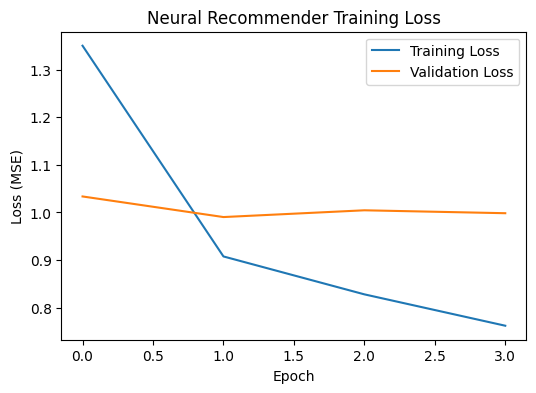

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Neural Recommender Training Loss")

plt.legend()

plt.show()

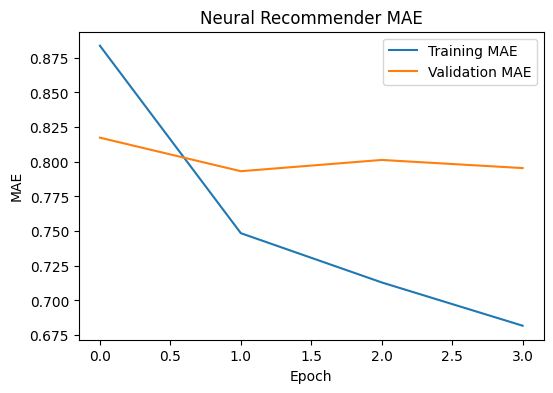

In [79]:
plt.figure(figsize=(6,4))

plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Neural Recommender MAE")

plt.legend()

plt.show()

### Interpretation of Training Curves

The training loss decreases steadily across epochs, indicating that the
neural network is successfully learning patterns from the training data.
The validation loss initially decreases and then stabilizes with only
minor fluctuations.

This suggests that the model is learning useful representations without
severe overfitting. Although the gap between training and validation
loss increases slightly, the validation loss remains relatively stable,
indicating that the model maintains reasonable generalization to unseen
data.

To further reduce the risk of overfitting, dropout layers were added to
the neural network architecture and early stopping was used during
training. Early stopping monitors the validation loss and stops training
when the model performance on the validation set stops improving.

In [80]:
def recommend_nn(user_id, top_n=10):

    rated_movies = ratings[ratings['userId'] == user_id]['movieId'].values

    candidates = [m for m in movie_ids if m not in rated_movies]

    movie_indices = [movie_to_index[m] for m in candidates]

    user_idx = user_to_index[user_id]
    user_array = np.full(len(movie_indices), user_idx)

    movie_array = np.array(movie_indices)

    preds = model.predict([user_array, movie_array], verbose=0).flatten()

    predictions = list(zip(candidates, preds))

    predictions.sort(key=lambda x: x[1], reverse=True)

    top_movies = predictions[:top_n]

    movie_ids_list = [m[0] for m in top_movies]

    results = movies[movies['movieId'].isin(movie_ids_list)][['title']]

    results['predicted_rating'] = np.round([m[1] for m in top_movies], 2)

    return results

In [81]:
recommend_nn(4)

,title,predicted_rating
277,"Shawshank Redemption, The (1994)",4.06
704,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),4.04
976,Cyrano de Bergerac (1990),4.03
983,"Big Sleep, The (1946)",4.03
2375,"Last Picture Show, The (1971)",4.03
5110,Gladiator (1992),4.01
6939,Dear Zachary: A Letter to a Son About His Fath...,4.01
7704,The Artist (2011),4.01
9301,Captain Fantastic (2016),3.99
9618,"Three Billboards Outside Ebbing, Missouri (2017)",3.99


In [82]:
recommend_nn(25)

,title,predicted_rating
277,"Shawshank Redemption, The (1994)",5.14
680,"Philadelphia Story, The (1940)",5.14
704,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),5.13
922,"Godfather: Part II, The (1974)",5.13
983,"Big Sleep, The (1946)",5.09
2375,"Last Picture Show, The (1971)",5.08
5110,Gladiator (1992),5.08
6939,Dear Zachary: A Letter to a Son About His Fath...,5.08
7704,The Artist (2011),5.08
9301,Captain Fantastic (2016),5.06


# Task 9: Reinforcement Learning in Recommender Systems

In reinforcement learning based recommender systems, the recommendation
process is treated as a sequential decision-making problem.

The recommender system acts as an agent that interacts with users. At
each step, the agent recommends a movie and receives feedback in the
form of a reward.

In this section we implement two reinforcement learning approaches:

- Multi-Armed Bandit using ε-greedy strategy
- Q-Learning based recommendation

## Multi-Armed Bandit Recommendation

In the multi-armed bandit setting, each movie can be considered as an
"arm". The system selects movies based on estimated rewards while also
exploring new movies occasionally.

The ε-greedy strategy balances exploration and exploitation:

- With probability ε → explore a random movie
- With probability (1 − ε) → recommend the movie with the highest reward

In [83]:
epsilon = 0.1

movie_rewards = {m:0 for m in movie_ids}
movie_counts = {m:0 for m in movie_ids}

In [84]:
def get_reward(user_id, movie_id):

    user_data = ratings[(ratings['userId']==user_id) &
                        (ratings['movieId']==movie_id)]

    if len(user_data)==0:
        return 0

    rating = user_data['rating'].values[0]

    if rating >= 4:
        return 1
    else:
        return 0

In [85]:
import random

def bandit_recommend(user_id):

    if random.random() < epsilon:
        movie_id = random.choice(movie_ids)
    else:
        movie_id = max(movie_rewards, key=movie_rewards.get)

    reward = get_reward(user_id, movie_id)

    movie_counts[movie_id] += 1

    movie_rewards[movie_id] += (
        reward - movie_rewards[movie_id]
    ) / movie_counts[movie_id]

    return movie_id, reward

In [86]:
for _ in range(1000):

    user = random.choice(user_ids)

    bandit_recommend(user)

In [87]:
sorted_movies = sorted(
    movie_rewards.items(),
    key=lambda x: x[1],
    reverse=True
)

top_movies = [m[0] for m in sorted_movies[:10]]

movies[movies['movieId'].isin(top_movies)][['title']]

,title
0,Toy Story (1995)
2,Grumpier Old Men (1995)
5,Heat (1995)
43,Seven (a.k.a. Se7en) (1995)
46,"Usual Suspects, The (1995)"
62,From Dusk Till Dawn (1996)
89,Bottle Rocket (1996)
97,Braveheart (1995)
124,Rob Roy (1995)
130,Canadian Bacon (1995)


### Observation

The multi-armed bandit approach learns which movies tend to generate
positive rewards based on user feedback. By balancing exploration and
exploitation, the recommender system gradually improves its
recommendations over time.

## Q-Learning Recommendation

Q-learning is a reinforcement learning algorithm that learns the value
of taking a specific action in a given state.

In this simplified recommender setting:

- State → User
- Action → Recommended movie
- Reward → User feedback based on rating

In [88]:
alpha = 0.1
gamma = 0.9

Q = {}

In [89]:
def q_learning_step(user_id):

    movie_id = random.choice(movie_ids)

    reward = get_reward(user_id, movie_id)

    key = (user_id, movie_id)

    if key not in Q:
        Q[key] = 0

    Q[key] = Q[key] + alpha * (reward - Q[key])

In [90]:
for _ in range(5000):

    user = random.choice(user_ids)

    q_learning_step(user)

In [91]:
def recommend_q(user_id, top_n=10):

    user_movies = [(m, Q.get((user_id,m),0)) for m in movie_ids]

    user_movies.sort(key=lambda x:x[1], reverse=True)

    movie_ids_list = [m[0] for m in user_movies[:top_n]]

    return movies[movies['movieId'].isin(movie_ids_list)][['title']]

In [92]:
recommend_q(50)

,title
0,Toy Story (1995)
2,Grumpier Old Men (1995)
5,Heat (1995)
43,Seven (a.k.a. Se7en) (1995)
46,"Usual Suspects, The (1995)"
62,From Dusk Till Dawn (1996)
89,Bottle Rocket (1996)
97,Braveheart (1995)
124,Rob Roy (1995)
130,Canadian Bacon (1995)


In [93]:
recommend_q(25)

,title
0,Toy Story (1995)
2,Grumpier Old Men (1995)
5,Heat (1995)
43,Seven (a.k.a. Se7en) (1995)
46,"Usual Suspects, The (1995)"
62,From Dusk Till Dawn (1996)
89,Bottle Rocket (1996)
97,Braveheart (1995)
124,Rob Roy (1995)
130,Canadian Bacon (1995)


### Comparison with Traditional Recommenders

Unlike traditional recommender systems that rely on historical ratings,
reinforcement learning methods continuously update recommendations based
on user feedback. This allows the system to adapt dynamically as user
preferences evolve.

However, reinforcement learning models require continuous interaction
data and careful balancing between exploration and exploitation.

# Part 6: Explainability in Recommender Systems

Modern recommender systems often act as "black boxes", making it
difficult for users to understand why certain items are recommended.
Explainable recommendation techniques aim to provide transparency by
showing the factors that influenced recommendations.

In this section we implement three types of explanations:

1. Feature-based explanations for content-based filtering
2. Neighborhood-based explanations for collaborative filtering
3. Model-agnostic explanations using SHAP

## Task 10: Feature-Based Explanations

Content-based recommender systems use item features such as genres
to compute similarity between movies. Therefore, recommendations can
be explained by identifying shared features between the recommended
movie and movies previously liked by the user.

For example, if a user enjoys science fiction movies, the system may
recommend other movies with similar genre attributes.

In [105]:
def explain_content_based(movie_title):

    idx = indices[movie_title]

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:6]

    movie_indices = [i[0] for i in sim_scores]

    similar_movies = movies.iloc[movie_indices]

    print("Recommended because you liked:", movie_title)
    print("\nSimilar movies with overlapping genres:\n")

    for _, row in similar_movies.iterrows():
        print(row['title'], "→ Genres:", row['genres'])

In [106]:
explain_content_based("Toy Story (1995)")

Recommended because you liked: Toy Story (1995)

Similar movies with overlapping genres:

Toy Story 2 (1999) → Genres: Adventure Animation Children Comedy Fantasy
Toy Story 3 (2010) → Genres: Adventure Animation Children Comedy Fantasy IMAX
Toy, The (1982) → Genres: Comedy
We're Back! A Dinosaur's Story (1993) → Genres: Adventure Animation Children Fantasy
Now and Then (1995) → Genres: Children Drama


## Task 11: Neighborhood-Based Explanations

Collaborative filtering recommendations are influenced by similar
users or similar items. Therefore, explanations can be generated by
showing which users or movies contributed to the recommendation.

Users with similar rating behavior are considered neighbors and their
ratings influence the prediction.

In [107]:
def explain_collaborative(user_id):

    similar_users = get_similar_users(user_id)

    print("Users with similar preferences to user", user_id)
    print(similar_users)

In [109]:
explain_collaborative(17)

Users with similar preferences to user 17
userId
16     0.456096
400    0.452319
434    0.452304
247    0.438913
399    0.414196
Name: 17, dtype: float64


## Task 12: Model-Agnostic Explainability

Neural network models often behave as black-box systems. Model-agnostic
techniques such as SHAP (SHapley Additive Explanations) help interpret
predictions by estimating how input features contribute to the final
prediction.

In this experiment SHAP is used to analyze the neural recommender model.

In [110]:
import shap
import numpy as np

In [111]:
def shap_predict(X):

    users = X[:,0].astype(int)
    movies = X[:,1].astype(int)

    return model.predict([users, movies], verbose=0)

In [112]:
X_shap = np.column_stack((X_user, X_movie))

background = X_shap[:50]
samples = X_shap[:20]

In [113]:
explainer = shap.KernelExplainer(
    shap_predict,
    background
)

In [114]:
shap_values = explainer.shap_values(samples)

  0%|          | 0/20 [00:00<?, ?it/s]

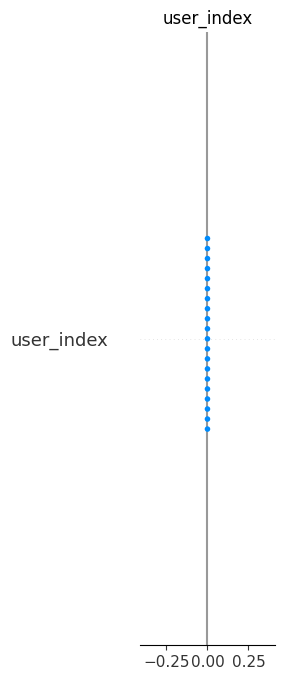

In [115]:
shap.summary_plot(
    shap_values,
    samples,
    feature_names=["user_index", "movie_index"]
)

### Interpretation of SHAP Results

The SHAP visualization shows how input features influence predictions
in the neural recommender model. In this model the inputs correspond to
user indices and movie indices, which are mapped internally to
embedding vectors.

Because these inputs represent identifiers rather than interpretable
features such as genres, the SHAP values mainly reflect the influence
of learned embeddings on the predicted rating. Nevertheless, the
analysis demonstrates how model-agnostic explainability techniques can
be applied to neural recommender systems.

### Task 13: Evaluating Explainability

Different explanation methods provide different levels of insight into
how recommendations are generated. Each method helps users understand
the recommender system from a different perspective.

**1. Feature-Based Explanations**

Feature-based explanations are easy for users to understand because
they rely on interpretable attributes such as movie genres. For example,
a system may recommend a movie because it shares similar genres with
movies the user previously liked. This approach makes recommendations
clear and intuitive for users since the explanation directly references
observable movie characteristics.

**2. Neighborhood-Based Explanations**

Neighborhood explanations are based on collaborative filtering and show
which similar users or items influenced the recommendation. For example,
a recommendation may be explained by stating that users with similar
preferences also enjoyed the recommended movie. This type of explanation
provides social context and can increase user trust in the system.

**3. Model-Agnostic Explanations**

Model-agnostic techniques such as SHAP provide explanations for complex
models such as neural networks. These methods estimate how input
features contribute to predictions, helping developers understand how
the model makes decisions. However, these explanations can be more
technical and may be less intuitive for non-expert users.

### Do explanations make recommendations clearer?

Yes, explanations make recommendations clearer because they provide
users with reasons for why certain items are suggested. When users
understand the reasoning behind recommendations, they are more likely
to trust the system and accept its suggestions.

### Do explanations reveal biases in recommendations?

Yes, explainability techniques can reveal biases in recommendation
systems. For example, content-based explanations may show that the
system heavily favors certain genres, while collaborative filtering
may over-recommend popular movies. Identifying such patterns helps
developers detect and mitigate biases in the recommendation process.

# Conclusion

In this assignment multiple recommendation techniques were implemented
and evaluated, including content-based filtering, collaborative
filtering, matrix factorization, hybrid recommenders, neural network
based recommenders, and reinforcement learning approaches.

Content-based filtering provided simple and interpretable
recommendations based on movie features such as genres. Collaborative
filtering leveraged user behavior patterns to generate personalized
suggestions. Matrix factorization techniques captured latent
relationships between users and items and improved prediction accuracy.

The neural network recommender learned user and movie embeddings and
was able to model more complex interactions in the data. Reinforcement
learning methods demonstrated how recommendation strategies can adapt
based on user feedback.

Finally, explainability techniques were used to interpret the
recommendations generated by different models. Feature-based,
neighborhood-based, and model-agnostic explanations help improve
transparency and user trust in recommender systems.